In [76]:
!python -m pip install langchain langchain-community langchain-qdrant langchain-huggingface qdrant-client sentence-transformers python-dotenv

   ---------------------------------------- 0.0/5.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.0 MB ? eta -:--:--
   -- ------------------------------------- 0.3/5.0 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/5.0 MB 1.1 MB/s eta 0:00:05
   ------ --------------------------------- 0.8/5.0 MB 1.0 MB/s eta 0:00:05
   ------ --------------------------------- 0.8/5.0 MB 1.0 MB/s eta 0:00:05
   -------- ------------------------------- 1.0/5.0 MB 996.7 kB/s eta 0:00:04
   ---------- ----------------------------- 1.3/5.0 MB 1.0 MB/s eta 0:00:04
   ------------ --------------------------- 1.6/5.0 MB 969.0 kB/s eta 0:00:04
   -------------- ------------------------- 1.8/5.0 MB 1.0 MB/s eta 0:00:04
   -------------- ------------------------- 1.8/5.0 MB 1.0 MB/s eta 0:00:04
   ---------------- ----------------------- 2.1/5.0 MB 1.0 MB/s eta 0:00:03
   ------------------ --------------------- 2.4/5.0 MB 1.0 MB/s eta 0:00:03
   -------------------- -----

In [3]:
import pandas as pd

# Login using e.g. `huggingface-cli login` to access this dataset
df = pd.read_json("hf://datasets/Amod/mental_health_counseling_conversations/combined_dataset.json", lines=True)

C:\Users\moham\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
pd.set_option('display.max_colwidth', None)

In [12]:
print(df['Context'].str.len().max() ,  " at index =>" ,  df['Context'].str.len().argmax())

2703  at index => 2308


In [13]:
print(df['Response'].str.len().max() ,  " at index =>" ,  df['Response'].str.len().argmax())

32739  at index => 2624


In [19]:
print(df.iloc[2308])

Context     Every once and a while, I think about my ex-boyfriend from four years ago, and my current friend. It’s like I can't get past it, and I need some kind of closure. I keep thinking about how we had something, but it got cut off due to parental intervention. Nothing was ever wrong with it. Now we've become friends, but there's this huge sexual tension between us, or at least I feel it when we're physically in the same place.\r\n\r\nTwo summers ago, we saw each other casually for a while, but we never had sex then or while we were dating, which was only for two months three years ago. I'm now in my 20s, and my current boyfriend is amazing and in his 30s. Despite the age difference, I know we're a really good match. We've never really fought and are able to make compromises and talk everything out. I tell him everything. Also, my ex-boyfriend has a girlfriend now as well. He’s been seeing her on and off for the past two and a half years, besides when they broke up and we had our 

In [20]:
print(df.iloc[2624])

Context                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [21]:
df[df['Response'].str.contains("img")]

,Context,Response
2487,I've recently thought that i could be transgender but I've never had the mind of a girl.,"Hello Frostproof,Thinking about becoming transgender and being transgender are slightly different. This is a topic that is best discussed with a therapist that specializes in LGBTQ issues. From what you have written it sounds as if you still have some confusion as to where you fit in with the ""labeling system"". While labels provide a means to quickly identify and classify, they can also feel restrictive or confining. Instead of focusing on fitting into a specific classification, explore who you are as a person and celebrate your positive qualities and those things that make you uniquely you! There are many options for you to find a therapist and e-therapy is also an option. You can try Breakthrough an online service. Here is some reading for refection that you may find helpful. Yin Yang Woman Man http://dld.bz/ejVK2 What does it mean to be a woman or a man?<img src="""
2624,"I get so much anxiety, and I don’t know why. I feel like I can’t do anything by myself because I’m scared of the outcomes.","The other two post answers to your question are very good and I don't feel the need to repeat what has already been said quite well, but I will offer one other option I have been able to utilize quite successfully with those dealing with panic attacks. Chain analysis is a fantastic way for your to map out the situation starting with the prompting event, the chain of events ((links) that lead up to the behavior - in this case a panic attack, and then what the consequences were. See the illustration below:<img src="""


* i have found many Duplicates Contexts&Responses, But no problems, we will make k retrieved greater than the most repetitive cell -_*

In [28]:
df[df['Context'].duplicated().sort_values()]

/tmp/ipykernel_2102/3778930241.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['Context'].duplicated().sort_values()]


,Context,Response
1,"I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.\n I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.\n How can I change my feeling of being worthless to everyone?","Hello, and thank you for your question and seeking advice on this. Feelings of worthlessness is unfortunately common. In fact, most people, if not all, have felt this to some degree at some point in their life. You are not alone. Changing our feelings is like changing our thoughts - it's hard to do. Our minds are so amazing that the minute you change your thought another one can be right there to take it's place. Without your permission, another thought can just pop in there. The new thought may feel worse than the last one! My guess is that you have tried several things to improve this on your own even before reaching out on here. People often try thinking positive thoughts, debating with their thoughts, or simply telling themselves that they need to ""snap out of it"" - which is also a thought that carries some self-criticism. Some people try a different approach, and there are counselors out there that can help you with this. The idea is that instead of trying to change the thoughts, you change how you respond to them. You learn skills that allow you to manage difficult thoughts and feelings differently so they don't have the same impact on you that they do right now. For some people, they actually DO begin to experience less hurtful thoughts once they learn how to manage the ones they have differently. Acceptance and Commitment Therapy may be a good choice for you. There is information online and even self-help books that you can use to teach you the skills that I mentioned. Because they are skills, they require practice, but many people have found great relief and an enriched life by learning them. As for suicidal thoughts, I am very glad to read that this has not happened to you. Still, you should watch out for this because it can be a sign of a worsening depression. If you begin to think about this, it is important to reach out to a support system right away. The National Suicide Prevention Lifeline is 1-800-273-8255. The text line is #741741. I hope some other colleagues will provide you more suggestions. Be well...Robin Landwehr, DBH, LPCC"
2,"I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.\n I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.\n How can I change my feeling of being worthless to everyone?",First thing I'd suggest is getting the sleep you need or it will impact how you think and feel. I'd look at finding what is going well in your life and what you can be grateful for. I believe everyone has talents and wants to find their purpose in life. I think you can figure it out with some help.
3,"I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.\n I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.\n How can I change my feeling of being worthless to everyone?","Therapy is essential for those that are feeling depressed and worthless. When I work with those that are experiencing concerns related to feeling of depression and issues with self esteem. I generally work with my client to help build coping skills to reduce level of depression and to assist with strengthening self esteem, by guiding my client with CBT practices. CBT helps with gaining a better awareness of how your thought process influences your belief system, and how your beliefs impact your actions and the outcome of your behaviors. This process isn’t easy but it helps teach an individual t

we have 94 respons to the same Context !!

In [59]:
df['Context'].value_counts()

Context
I have so many issues to address. I have a history of sexual abuse, I’m a breast cancer survivor and I am a lifetime insomniac.    I have a long history of depression and I’m beginning to have anxiety. I have low self esteem but I’ve been happily married for almost 35 years.\n   I’ve never had counseling about any of this. Do I have too many issues to address in counseling?                                                        94
How does a counselor decide when to end counseling sessions or to terminate working with a client?                                                                                                                                                                                                                                                                                                                                              55
I've gone to a couple therapy sessions so far and still everytime I walk in I get nervous and shaky. Is this normal? Shoul

In [60]:
df['Response'].value_counts()

Response
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [21]:
# df.drop(df.index[2624], inplace=True)

In [23]:
df['Response'].str.len().argmax()

np.int64(2487)

<Axes: >

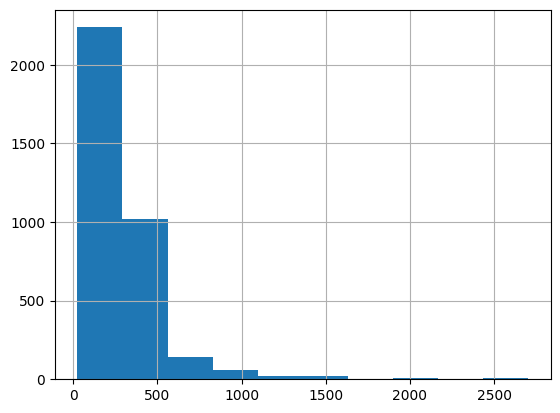

In [22]:
df['Context'].str.len().hist()

In [30]:
df['Response'].str.len().sort_values()[-3:]

815      5499
2487    31495
2624    32739
Name: Response, dtype: int64

In [61]:
print(df.iloc[2487])

Context                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            I've recently thought that i could be transgender but I've never had the mind of a girl.
Response    Hello Frostproof,Thinking about becoming transgender and being transgender are slightly differen

In [34]:
print(df.iloc[2624])

Context                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [35]:
import re

In [42]:
df.loc[[2624, 2487], 'Response'] = df.loc[[2624, 2487], 'Response'].str.replace(r'<img.*', '', regex=True)

In [43]:
# After cut these linsks
df['Response'].str.len().sort_values()[-3:]

3144    5250
897     5250
815     5499
Name: Response, dtype: int64

In [44]:
# DONE!!!
# responses is ready now

In [45]:
df['Context'].str.len().sort_values()[-3:]


1014    2591
1643    2702
2308    2703
Name: Context, dtype: int64

In [46]:
# Context is OK too

* now we will try to solve the problem of having one Context with many Responses by Clustring them and pick most informative for each cluster
* "Done in Clustered Data set .csv file, Skip for now just test RAG now

In [12]:
!python -m pip install langchain_community langchain_groq


   ------------- -------------------------- 1/3 [groq]
   ------------- -------------------------- 1/3 [groq]
   ------------- -------------------------- 1/3 [groq]
   ------------- -------------------------- 1/3 [groq]
   ------------- -------------------------- 1/3 [groq]
   ------------- -------------------------- 1/3 [groq]
   ------------- -------------------------- 1/3 [groq]
   ---------------------------------------- 3/3 [langchain_groq]



  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
from langchain_community.document_loaders.csv_loader import CSVLoader

C:\Users\moham\AppData\Local\Temp\ipykernel_2064\583992377.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders.csv_loader import CSVLoader
C:\Users\moham\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\langchain_core\utils\pydantic.py:41: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


In [2]:
loader = CSVLoader("mental_health_preprocessed.csv", encoding="utf-8",
                   source_column="Context",
                    metadata_columns=["Response"]
                   )
docs = loader.load()

In [3]:
docs[0]

Document(metadata={'source': "I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.\n   I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.\n   How can I change my feeling of being worthless to everyone?", 'row': 0, 'Response': "If everyone thinks you're worthless, then maybe you need to find new people to hang out with.Seriously, the social context in which a person lives is a big influence in self-esteem.Otherwise, you can go round and round trying to understand why you're not worthless, then go back to the same crowd and be knocked down again.There are many inspirational messages you can find in social media. \xa0Maybe read some of the ones which state that no person is worthless, and that everyone has a good purpose to their life.Also, since our culture is so saturated with the belief that if someone doesn't feel good about the

In [89]:
!python -m pip install accelerate

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [13]:
import os
os.environ["HF_TOKEN"] = "..."
os.environ["GROQ_API_KEY"] = "..."

In [14]:
"""
Mental Health RAG Chain — Full LangChain Pipeline
==================================================
Builds a complete RAG chain:
  retriever (Qdrant) → prompt → LLM → answer

Requirements:
    pip install langchain langchain-community langchain-qdrant
                langchain-huggingface langchain-openai
                qdrant-client sentence-transformers python-dotenv
"""

import os
from dotenv import load_dotenv

from langchain_community.document_loaders import CSVLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import QdrantVectorStore
# from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableLambda

from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams
from langchain_huggingface import HuggingFacePipeline
from transformers import pipeline
import traceback
from langchain_huggingface import HuggingFaceEndpoint
from langchain_groq import ChatGroq

load_dotenv()

# ── Config ────────────────────────────────────────────────────────────────────

CSV_PATH        = "mental_health_preprocessed.csv"
COLLECTION_NAME = "mental_health_counseling"
EMBEDDING_MODEL = "all-MiniLM-L6-v2"
EMBEDDING_DIM   = 384
TOP_K           = 8

QDRANT_URL      = os.getenv("QDRANT_URL")
QDRANT_API_KEY  = os.getenv("QDRANT_API_KEY")

def load_embedding_model():
    print("Loading embeddings model ...")
    embeddings = HuggingFaceEmbeddings(
        model_name=EMBEDDING_MODEL,
        model_kwargs={"device": "cpu"},
        encode_kwargs={"normalize_embeddings": True},
    )
    return  embeddings

# ── 1. Load & index (first run only) ─────────────────────────────────────────

def build_vector_store(force_recreate: bool = False) -> QdrantVectorStore:
    # print("Loading documents ...")
    # loader = CSVLoader(
    #     file_path=CSV_PATH,
    #     encoding="utf-8-sig",
    #     source_column="Context",
    #     metadata_columns=["Response"],
    # )
    # docs = loader.load()
    # print(f"  {len(docs):,} documents loaded.")

    embeddings = load_embedding_model()

    client = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY)
    existing = [c.name for c in client.get_collections().collections]

    if COLLECTION_NAME not in existing or force_recreate:
        try:
            print(f"Indexing into Qdrant collection '{COLLECTION_NAME}' ...")
            vector_store = QdrantVectorStore.from_documents(
                documents=docs,
                embedding=embeddings,
                url=QDRANT_URL,
                api_key=QDRANT_API_KEY,
                collection_name=COLLECTION_NAME,
                force_recreate=force_recreate,
                batch_size=128,
                timeout=120.0
            )
            print("  Indexing complete.")
        except Exception as e:
            print(f"FAILED at batch: {e}")
            traceback.print_exc()
    else:
        print(f"Collection '{COLLECTION_NAME}' exists — connecting without re-indexing.")
        vector_store = QdrantVectorStore.from_existing_collection(
            embedding=embeddings,
            url=QDRANT_URL,
            api_key=QDRANT_API_KEY,
            collection_name=COLLECTION_NAME,
        )

    return vector_store


# ── 2. Retriever ──────────────────────────────────────────────────────────────

def get_retriever(vector_store: QdrantVectorStore):
    return vector_store.as_retriever(
        search_type="similarity",
        search_kwargs={"k": TOP_K},
    )


# ── 3. Format retrieved docs into prompt context ──────────────────────────────

def format_docs(docs) -> str:
    pairs = []
    for doc in docs:
        q = doc.page_content
        a = doc.metadata.get("Response", "")
        pairs.append(f"Client: {q}\nCounselor: {a}")
    return "\n\n---\n\n".join(pairs)


# ── 4. Prompt ─────────────────────────────────────────────────────────────────

SYSTEM_PROMPT = """You are a compassionate and professional mental health counselor assistant.
Use the following real counselor responses to similar situations as guidance.
Respond with empathy, warmth, and evidence-based support.
Do NOT copy the examples verbatim — use them only to inform your response.
If the situation seems like a crisis, always recommend professional help or a crisis hotline.

Similar counseling examples:
{context}"""

prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_PROMPT),
    ("human", "{question}"),
])


# ── 5. LLM ────────────────────────────────────────────────────────────────────


def get_llm():
    return ChatGroq(
        model="llama-3.3-70b-versatile",
        temperature=0.7,
        api_key=os.getenv("GROQ_API_KEY"),
    )

    # ── Alternatives ──────────────────────────────────────────────────────────
    # Anthropic Claude:
    # from langchain_anthropic import ChatAnthropic
    # return ChatAnthropic(model="claude-3-5-haiku-20241022", temperature=0.7)

    # Ollama (local):
    # from langchain_ollama import ChatOllama
    # return ChatOllama(model="llama3.2", temperature=0.7)

    # Google Gemini:
    # from langchain_google_genai import ChatGoogleGenerativeAI
    # return ChatGoogleGenerativeAI(model="gemini-2.0-flash", temperature=0.7)


# ── 6. Build the full RAG chain ───────────────────────────────────────────────

def build_rag_chain(retriever, llm):
    """
    Chain layout:
        question
            ├─→ retriever → format_docs → context
            └─→ passthrough             → question
                        ↓
                      prompt
                        ↓
                        llm
                        ↓
                  StrOutputParser → answer string
    """
    rag_chain = (
        {
            "context":  retriever | RunnableLambda(format_docs),
            "question": RunnablePassthrough(),
        }
        | prompt
        | llm
        | StrOutputParser()
    )
    return rag_chain


# ── 7. Optional: chain that also returns source docs ─────────────────────────

def build_rag_chain_with_sources(retriever, llm):
    """
    Returns {"answer": "...", "source_docs": [...]} so you can
    inspect which examples were retrieved.
    """
    from langchain_core.runnables import RunnableParallel

    retrieve_and_format = RunnableParallel(
        context=retriever | RunnableLambda(format_docs),
        question=RunnablePassthrough(),
        source_docs=retriever,
    )

    answer_chain = (
        {
            "context":  RunnableLambda(lambda x: x["context"]),
            "question": RunnableLambda(lambda x: x["question"]),
        }
        | prompt
        | llm
        | StrOutputParser()
    )

    def run(question: str) -> dict:
        retrieved = retrieve_and_format.invoke(question)
        answer = answer_chain.invoke(retrieved)
        return {
            "answer": answer,
            "source_docs": retrieved["source_docs"],
        }

    return run


# ── Main ──────────────────────────────────────────────────────────────────────
vector_store = build_vector_store(force_recreate=False)
retriever    = get_retriever(vector_store)
llm          = get_llm()
#
# # ── Basic chain ───────────────────────────────────────────────────────────
# rag_chain = build_rag_chain(retriever, llm)
#
# print("\n" + "="*60)
# question = "I've been feeling really anxious and can't stop overthinking everything at night."
# print(f"Question: {question}\n")
# answer = rag_chain.invoke(question)
# print(f"Answer:\n{answer}")
# print("="*60 + "\n")
#
# if __name__ == "__main__":
#
#     # Build / connect to vector store
#     vector_store = build_vector_store(force_recreate=True)
#     retriever    = get_retriever(vector_store)
#     llm          = get_llm()
#
#     # ── Basic chain ───────────────────────────────────────────────────────────
#     rag_chain = build_rag_chain(retriever, llm)
#
#     print("\n" + "="*60)
#     question = "I've been feeling really anxious and can't stop overthinking everything at night."
#     print(f"Question: {question}\n")
#     answer = rag_chain.invoke(question)
#     print(f"Answer:\n{answer}")
#     print("="*60 + "\n")
#
#     # ── Chain with sources ────────────────────────────────────────────────────
#     rag_with_sources = build_rag_chain_with_sources(retriever, llm)
#
#     result = rag_with_sources("I feel worthless and don't see the point of anything.")
#     print(f"Answer:\n{result['answer']}\n")
#     print("Retrieved examples:")
#     for i, doc in enumerate(result["source_docs"], 1):
#         print(f"  [{i}] Context : {doc.page_content[:80]}...")
#         print(f"       Response: {doc.metadata['Response'][:80]}...")

Loading embeddings model ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Collection 'mental_health_counseling' exists — connecting without re-indexing.


In [15]:
# ── Basic chain ───────────────────────────────────────────────────────────
rag_chain = build_rag_chain(retriever, llm)

print("\n" + "="*60)
question = "I've been feeling really anxious and can't stop overthinking everything at night."
print(f"Question: {question}\n")
answer = rag_chain.invoke(question)
print(f"Answer:\n{answer}")
print("="*60 + "\n")


Question: I've been feeling really anxious and can't stop overthinking everything at night.

Answer:
I can sense how overwhelming and exhausting that must feel for you. It's like your mind is racing with thoughts and worries, making it impossible to relax and unwind, especially at night. 

Firstly, please know that you're not alone in this. Many people experience anxiety and overthinking, and it's not a sign of weakness or failure. It's actually a sign that your mind is trying to process and make sense of the world around you.

One thing that might be helpful is to explore what might be driving these anxious thoughts and feelings. Are there any specific concerns or stressors in your life that could be contributing to your anxiety? Sometimes, identifying the root cause of our worries can help us address them more effectively.

In the meantime, here are a few strategies that might help you calm your mind and reduce overthinking at night:

1. **Practice relaxation techniques**: Regular r

In [17]:
rag_with_sources = build_rag_chain_with_sources(retriever, llm)

result = rag_with_sources("I feel worthless and don't see the point of anything.")
print(f"Answer:\n{result['answer']}\n")
print("Retrieved examples:")
for i, doc in enumerate(result["source_docs"], 1):
    print(f"  [{i}] Context : {doc.page_content[:80]}...")
    print(f"       Response: {doc.metadata['Response'][:80]}...")

Answer:
I'm so sorry to hear that you're feeling this way. It takes a lot of courage to acknowledge and share these feelings, and I'm here to listen and support you. Feeling worthless and hopeless can be a really painful and isolating experience, but please know that you're not alone. Many people have been where you are, and there is help available.

First, I want to acknowledge that your feelings are valid. It's okay to feel this way, and it doesn't mean that there's anything wrong with you. It's possible that you're struggling with some underlying issues, such as depression, anxiety, or low self-esteem, that are contributing to these feelings.

I want to encourage you to take small steps towards seeking help. This could be talking to a trusted friend or family member, reaching out to a mental health professional, or seeking support from a crisis hotline. Sometimes, just having someone to talk to can make a big difference.

In the meantime, I want to offer you some gentle suggestions 